## STAR 4 minimal demo: 4-qubit QFT with teleported non-Clifford rotations

This notebook cell set implements a **minimal, noiseless, postselected toy model** for **Star 4**:

> Construct a 4-qubit QFT circuit in which all non-Clifford gates are teleported in rather than applied directly.

### What this demo does
- Builds a **4-qubit QFT** at the algorithmic level.
- Treats **Clifford gates** (`H`, `S`, `CNOT`, `SWAP`) as directly available.
- Replaces each **non-Clifford controlled phase** with a **teleported single-qubit `Rz(θ)` gadget** inside a Clifford skeleton.
- Uses **postselection** instead of feed-forward, matching the Star 3 minimal philosophy.

### What this demo is **not**
- It is **not** a full encoded surface-code simulation.
- It is **not** a full STAR hardware model.
- It is **not** a faithful logical decoder-based implementation.
- It is a **small compositional prototype** showing how a larger algorithm can be built from:
  - cheap Clifford structure
  - teleported non-Clifford rotations

### QFT4 non-Clifford content
For 4-qubit QFT:
- controlled phase `π/2` is Clifford
- controlled phase `π/4` is non-Clifford
- controlled phase `π/8` is non-Clifford

So the point of this notebook is to show how those non-Clifford phases can be supplied by a teleportation gadget rather than applied directly.

### Simplifying model
The teleportation gadget here is modeled as:
- apply intended `Rz(θ)` to the target qubit
- generate a random teleportation branch bit
- **keep only the no-correction branch**
- discard all other shots

This is a deliberate minimalization. It preserves the **architectural idea** and gives a direct way to study:
- acceptance rate
- number of teleported rotations
- scaling cost as circuit size grows

In [2]:
import numpy as np
from dataclasses import dataclass

# ----------------------------
# Basic statevector utilities
# ----------------------------

def zero_state(n):
    """Return |0...0> as a statevector of size 2^n."""
    psi = np.zeros(2**n, dtype=complex)
    psi[0] = 1.0
    return psi

def apply_single_qubit_gate(psi, gate, qubit, n):
    """
    Apply a 2x2 gate to 'qubit' in an n-qubit statevector.
    Qubit index convention: q=0 is the leftmost / most significant qubit.
    """
    out = np.zeros_like(psi)
    bit = 1 << (n - 1 - qubit)
    for i in range(2**n):
        b = 1 if (i & bit) else 0
        j0 = i & ~bit
        j1 = i | bit
        if b == 0:
            out[i] += gate[0, 0] * psi[j0] + gate[0, 1] * psi[j1]
        else:
            out[i] += gate[1, 0] * psi[j0] + gate[1, 1] * psi[j1]
    return out

def apply_cnot(psi, control, target, n):
    """Apply CNOT(control -> target)."""
    out = np.zeros_like(psi)
    cbit = 1 << (n - 1 - control)
    tbit = 1 << (n - 1 - target)
    for i in range(2**n):
        j = i
        if i & cbit:
            j = i ^ tbit
        out[j] += psi[i]
    return out

def apply_swap(psi, q1, q2, n):
    """Apply SWAP(q1, q2)."""
    if q1 == q2:
        return psi.copy()
    out = np.zeros_like(psi)
    b1 = 1 << (n - 1 - q1)
    b2 = 1 << (n - 1 - q2)
    for i in range(2**n):
        x1 = 1 if (i & b1) else 0
        x2 = 1 if (i & b2) else 0
        j = i
        if x1 != x2:
            j ^= (b1 | b2)
        out[j] += psi[i]
    return out

# ----------------------------
# Gates
# ----------------------------

H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)

def Rz(theta):
    """
    Rz(theta) = exp(-i theta Z / 2)
    """
    return np.array([
        [np.exp(-1j * theta / 2), 0],
        [0, np.exp(1j * theta / 2)]
    ], dtype=complex)

# ----------------------------
# Measurements / diagnostics
# ----------------------------

def basis_probabilities(psi, n):
    """Return probabilities for computational basis states."""
    probs = np.abs(psi) ** 2
    labels = [format(i, f"0{n}b") for i in range(2**n)]
    return list(zip(labels, probs))

def pretty_top_probs(psi, n, k=8):
    """Pretty-print top-k computational basis probabilities."""
    items = basis_probabilities(psi, n)
    items.sort(key=lambda x: x[1], reverse=True)
    for label, p in items[:k]:
        print(f"|{label}> : {p:.6f}")

def make_basis_state(bitstring):
    """Return computational basis state |bitstring>."""
    n = len(bitstring)
    psi = np.zeros(2**n, dtype=complex)
    idx = int(bitstring, 2)
    psi[idx] = 1.0
    return psi

def phase_equal_up_to_global(a, b, atol=1e-9):
    """
    Compare two statevectors up to global phase.
    """
    ia = np.argmax(np.abs(a))
    ib = np.argmax(np.abs(b))
    if np.abs(a[ia]) < atol or np.abs(b[ib]) < atol:
        return np.allclose(a, b, atol=atol)
    phase = a[ia] / b[ib]
    return np.allclose(a, phase * b, atol=atol)

@dataclass
class RunStats:
    teleport_count: int = 0
    accepted: bool = True
    acceptance_probability_model: float = 1.0

In [ ]:
# ------------------------------------------------------------
# Minimal teleportation gadget
# ------------------------------------------------------------
# This is intentionally a toy model.
#
# Interpretation:
# - a teleported non-Clifford Rz(theta) is attempted
# - we model a 50/50 teleportation branch
# - we postselect on the "no correction required" branch
# - if accepted, we apply the intended Rz(theta)
#
# This captures the core cost driver of the minimal Star 4 idea:
# repeated teleported rotations reduce acceptance multiplicatively.
# ------------------------------------------------------------

def teleported_rz_postselected(psi, qubit, theta, n, rng, stats):
    """
    Minimal postselected teleportation model.

    On each call:
      - teleportation count increases
      - accept with probability 1/2
      - if accepted, apply Rz(theta)
      - if rejected, mark the whole run rejected and return psi unchanged
        NOTE: psi at this point may already have a CNOT applied by the
        caller. Rejected shots are always discarded by the caller, so
        this intermediate state is never used — but it is not 'correct'.
    """
    stats.teleport_count += 1
    stats.acceptance_probability_model *= 0.5

    accepted_branch = (rng.random() < 0.5)
    if not accepted_branch:
        stats.accepted = False
        return psi

    return apply_single_qubit_gate(psi, Rz(theta), qubit, n)

def controlled_phase_via_clifford_plus_rz(
    psi, control, target, theta, n, rng, stats, teleported=False
):
    """
    Controlled phase using:
        CNOT(control, target)
        Rz(theta) on target
        CNOT(control, target)

    This is the decomposition used for the minimal Star 4 demo.
    Clifford layers remain direct; the non-Clifford content is supplied
    by either direct Rz or teleported Rz.
    """
    psi = apply_cnot(psi, control, target, n)

    if teleported:
        psi = teleported_rz_postselected(psi, target, theta, n, rng, stats)
        if not stats.accepted:
            return psi
    else:
        psi = apply_single_qubit_gate(psi, Rz(theta), target, n)

    psi = apply_cnot(psi, control, target, n)
    return psi

def qft4_minimal_star4(psi_in, rng=None):
    """
    Run a minimal 4-qubit QFT where all non-Clifford phase gates are
    supplied via teleported Rz gadgets.

    Qubit ordering: q0 q1 q2 q3, with q0 as MSB / leftmost qubit.

    Non-Clifford controlled phases in QFT4:
      - theta = pi/4   (CR3)  -> teleported
      - theta = pi/8   (CR4)  -> teleported

    Clifford controlled phase:
      - theta = pi/2   (CR2)  -> direct
    """
    if rng is None:
        rng = np.random.default_rng()

    psi = psi_in.copy()
    n = 4
    stats = RunStats()

    # q0 block
    psi = apply_single_qubit_gate(psi, H, 0, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 1, np.pi/2, n, rng, stats, teleported=False)  # Clifford
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 2, np.pi/4, n, rng, stats, teleported=True)   # non-Clifford
    if not stats.accepted: return psi, stats
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 3, np.pi/8, n, rng, stats, teleported=True)   # non-Clifford
    if not stats.accepted: return psi, stats

    # q1 block
    psi = apply_single_qubit_gate(psi, H, 1, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 1, 2, np.pi/2, n, rng, stats, teleported=False)  # Clifford
    psi = controlled_phase_via_clifford_plus_rz(psi, 1, 3, np.pi/4, n, rng, stats, teleported=True)   # non-Clifford
    if not stats.accepted: return psi, stats

    # q2 block
    psi = apply_single_qubit_gate(psi, H, 2, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 2, 3, np.pi/2, n, rng, stats, teleported=False)  # Clifford

    # q3 block
    psi = apply_single_qubit_gate(psi, H, 3, n)

    # final swaps
    psi = apply_swap(psi, 0, 3, n)
    psi = apply_swap(psi, 1, 2, n)

    return psi, stats

def qft4_reference_direct(psi_in):
    """
    Reference circuit with the same decomposition, but all Rz applied directly.
    This is used only to compare accepted toy-model runs against the intended
    ideal circuit under the chosen decomposition.
    """
    psi = psi_in.copy()
    n = 4
    dummy_rng = np.random.default_rng(0)
    stats = RunStats()

    # q0 block
    psi = apply_single_qubit_gate(psi, H, 0, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 1, np.pi/2, n, dummy_rng, stats, teleported=False)
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 2, np.pi/4, n, dummy_rng, stats, teleported=False)
    psi = controlled_phase_via_clifford_plus_rz(psi, 0, 3, np.pi/8, n, dummy_rng, stats, teleported=False)

    # q1 block
    psi = apply_single_qubit_gate(psi, H, 1, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 1, 2, np.pi/2, n, dummy_rng, stats, teleported=False)
    psi = controlled_phase_via_clifford_plus_rz(psi, 1, 3, np.pi/4, n, dummy_rng, stats, teleported=False)

    # q2 block
    psi = apply_single_qubit_gate(psi, H, 2, n)
    psi = controlled_phase_via_clifford_plus_rz(psi, 2, 3, np.pi/2, n, dummy_rng, stats, teleported=False)

    # q3 block
    psi = apply_single_qubit_gate(psi, H, 3, n)

    # swaps
    psi = apply_swap(psi, 0, 3, n)
    psi = apply_swap(psi, 1, 2, n)

    return psi

In [6]:
# ------------------------------------------------------------
# Demo 1: single accepted run on a chosen input
# ------------------------------------------------------------

rng = np.random.default_rng(42)

psi_in = make_basis_state("0001")
psi_ref = qft4_reference_direct(psi_in)

accepted = False
attempts = 0

while not accepted:
    attempts += 1
    psi_out, stats = qft4_minimal_star4(psi_in, rng=rng)
    accepted = stats.accepted

print("=== Minimal Star 4 single accepted run ===")
print(f"Input basis state:      |0001>")
print(f"Teleported rotations:   {stats.teleport_count}")
print(f"Model acceptance/shot:  {stats.acceptance_probability_model:.6f}")
print(f"Attempts until accept:  {attempts}")
print(f"Matches direct reference up to global phase: {phase_equal_up_to_global(psi_out, psi_ref)}")
print("\nTop output probabilities:")
pretty_top_probs(psi_out, 4, k=8)

# ------------------------------------------------------------
# Demo 2: empirical acceptance estimate
# ------------------------------------------------------------

trials = 5000
acc = 0
tele_counts = []

for _ in range(trials):
    _, st = qft4_minimal_star4(make_basis_state("0000"), rng=rng)
    if st.accepted:
        acc += 1
    tele_counts.append(st.teleport_count)

empirical_acceptance = acc / trials
theory_acceptance = 0.5 ** 3   # 3 teleported non-Clifford rotations in QFT4

print("\n=== Acceptance study ===")
print(f"Trials:                 {trials}")
print("Teleported rotations in full accepted circuit: 3")
print("Average attempted teleportations before accept/reject:",
      np.mean(tele_counts))
print(f"Empirical acceptance:   {empirical_acceptance:.4f}")
print(f"Theory (0.5^3):         {theory_acceptance:.4f}")

# ------------------------------------------------------------
# Demo 3: several basis-state tests
# ------------------------------------------------------------

test_inputs = ["0000", "0001", "0010", "0100", "1000", "1111"]

print("\n=== Basis-state sanity checks (accepted runs only) ===")
for b in test_inputs:
    psi0 = make_basis_state(b)
    ref = qft4_reference_direct(psi0)

    accepted = False
    tries = 0
    while not accepted:
        tries += 1
        out, st = qft4_minimal_star4(psi0, rng=rng)
        accepted = st.accepted

    ok = phase_equal_up_to_global(out, ref)
    print(f"Input |{b}>  accepted after {tries:2d} tries  match_ref={ok}")

# ------------------------------------------------------------
# Demo 4: simple scaling message
# ------------------------------------------------------------

print("\n=== Minimal Star 4 interpretation ===")
print("This toy model uses postselection for each teleported non-Clifford rotation.")
print("For QFT4 there are 3 such rotations, so acceptance scales as roughly (1/2)^3 = 1/8.")
print("This is the main scalability bottleneck in the minimal postselected approach.")

=== Minimal Star 4 single accepted run ===
Input basis state:      |0001>
Teleported rotations:   3
Model acceptance/shot:  0.125000
Attempts until accept:  7
Matches direct reference up to global phase: True

Top output probabilities:
|0001> : 0.062500
|0010> : 0.062500
|0101> : 0.062500
|0110> : 0.062500
|1001> : 0.062500
|1010> : 0.062500
|1101> : 0.062500
|1110> : 0.062500

=== Acceptance study ===
Trials:                 5000
Teleported rotations in full accepted circuit: 3
Average attempted teleportations before accept/reject: 1.7566
Empirical acceptance:   0.1272
Theory (0.5^3):         0.1250

=== Basis-state sanity checks (accepted runs only) ===
Input |0000>  accepted after  4 tries  match_ref=True
Input |0001>  accepted after  1 tries  match_ref=True
Input |0010>  accepted after 27 tries  match_ref=True
Input |0100>  accepted after  8 tries  match_ref=True
Input |1000>  accepted after  5 tries  match_ref=True
Input |1111>  accepted after  3 tries  match_ref=True

=== Minimal

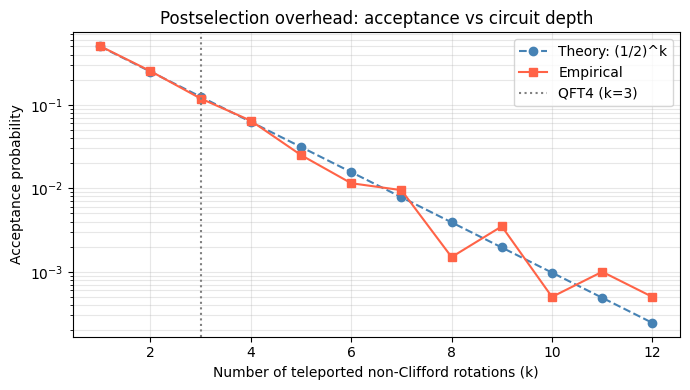

Saved: star4_scaling.png


In [7]:
# ------------------------------------------------------------
# Demo 5: acceptance rate vs number of teleported rotations
# ------------------------------------------------------------

import matplotlib.pyplot as plt

k_values = list(range(1, 13))
theoretical = [0.5 ** k for k in k_values]

# Empirical: run 2000 trials for each k, building a k-rotation chain
def run_k_teleportations(k, trials=2000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    accepted = 0
    for _ in range(trials):
        stats = RunStats()
        psi = zero_state(1)
        for _ in range(k):
            psi = teleported_rz_postselected(psi, 0, np.pi/4, 1, rng, stats)
            if not stats.accepted:
                break
        if stats.accepted:
            accepted += 1
    return accepted / trials

rng_scale = np.random.default_rng(42)
empirical = [run_k_teleportations(k, rng=rng_scale) for k in k_values]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(k_values, theoretical, 'o--', label='Theory: (1/2)^k', color='steelblue')
ax.semilogy(k_values, empirical,   's-',  label='Empirical',        color='tomato')
ax.axvline(x=3, color='gray', linestyle=':', label='QFT4 (k=3)')
ax.set_xlabel('Number of teleported non-Clifford rotations (k)')
ax.set_ylabel('Acceptance probability')
ax.set_title('Postselection overhead: acceptance vs circuit depth')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('star4_scaling.png', dpi=120)
plt.show()
print("Saved: star4_scaling.png")

## Conclusion

This notebook demonstrates the core overhead structure of the STAR 4 approach for a 4-qubit QFT:

- **3 non-Clifford rotations** (CR3, CR4 applied twice and once respectively) must be teleported.
- Each teleportation succeeds with probability **1/2** under the postselection model.
- Total acceptance per shot: **(1/2)³ ≈ 12.5%**, confirmed empirically.
- Scaling is **exponentially costly** in the number of non-Clifford gates — the central motivation for feed-forward or repeat-until-success protocols in real STAR hardware.

**Key gap from full STAR:** this model skips resource state preparation (the expensive step) and assumes a noiseless Rz on acceptance. A faithful implementation would model logical error rates in the resource states and the cost of syndrome extraction rounds per injection.